### The basic model

In [2]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import tqdm.notebook as tqdm

import holodeck as holo
from holodeck import sams
from holodeck import utils, plot
from holodeck.constants import MSOL, YR, PC

plt.style.use("/home/sam/work/sim.mplstyle")
plt.rcParams["figure.figsize"] = (6,6)

%config InlineBackend.figure_format = 'retina'

holo.log.setLevel(holo.log.ERROR)

## Config

In [3]:
shape = 30
NUM_REALS = int(1e3)
NUM_LOUDEST = 0
OBS_DUR = 15.0 * YR
NUM_FREQS = 30

gsmf = holo.sams.GSMF_Schechter()                    # Galaxy Stellar-Mass Function (GSMF)
gpf = holo.sams.GPF_Power_Law()                      # Galaxy Pair Fraction         (GPF)
gmt = holo.sams.GMT_Power_Law()                      # Galaxy Merger Time           (GMT)
mmbulge = holo.host_relations.MMBulge_MM2013()       # M-MBulge Relation            (MMB)
sam = holo.sams.Semi_Analytic_Model(
    mtot=(1e8*MSOL, 1e11*MSOL, 51),
    mrat=(0.001, 1, 51),
    redz=(0.001, 1, 51),
    gsmf=gsmf, gpf=gpf, gmt=gmt, mmbulge=mmbulge, shape=shape)

In [4]:
fobs, fobs_edges = utils.pta_freqs(dur=OBS_DUR, num=NUM_FREQS)
hard_gw = holo.hardening.Hard_GW()

lifetime = 1e9 * YR  ## <-- try changing this
gamma_inner = -1.0 ## <-- try changing this
hard_ph = holo.hardening.Fixed_Time_2PL_SAM(sam, lifetime, sepa_init=1.0e4*PC, gamma_inner=gamma_inner)
redz_final, diff_num = holo.sams.sam_cyutils.dynamic_binary_number_at_fobs(
    fobs/2, sam, hard_ph, holo.cosmo
)

# ---------------------- #

hc_ss_gw, hc_gw = sam.gwb(fobs_edges, hard = hard_gw, realize=NUM_REALS, loudest=NUM_LOUDEST)

hc_ss, hc_true = sam.gwb(fobs_edges, hard = hard_ph, realize=NUM_REALS, loudest=NUM_LOUDEST)

edges = [sam.mtot, sam.mrat, sam.redz, fobs_edges/2]
number = holo.sams.sam_cyutils.integrate_differential_number_3dx1d(edges, diff_num)

passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()


Effect of Hardening

(-16.0, -14.108119803171858)

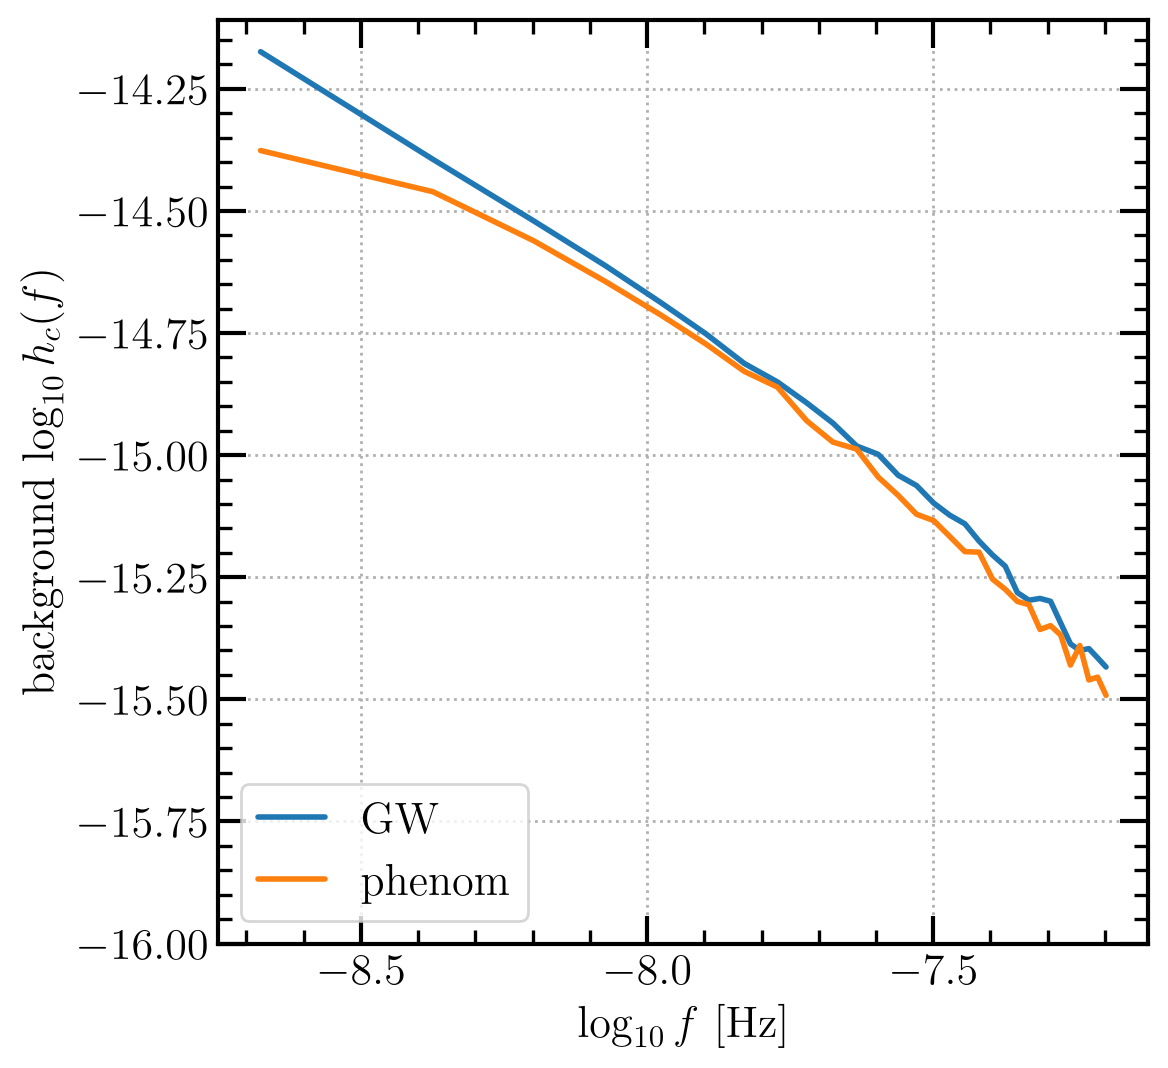

In [5]:
plt.plot(np.log10(fobs), np.log10(np.average(hc_gw,1)), lw=2,label=f'GW');
plt.plot(np.log10(fobs), np.log10(np.average(hc_true,1)), lw=2, label=f'phenom');
plt.legend(fontsize=16, loc='lower left')
plt.xlabel(r"$\log_{10} f$ [Hz]")
plt.ylabel(r'background $\log_{10} h_c(f)$')
plt.ylim(-16,)

### Checking sources properties 

Text(0, 0.5, '$\\Delta N_{J=0}/\\Delta q$')

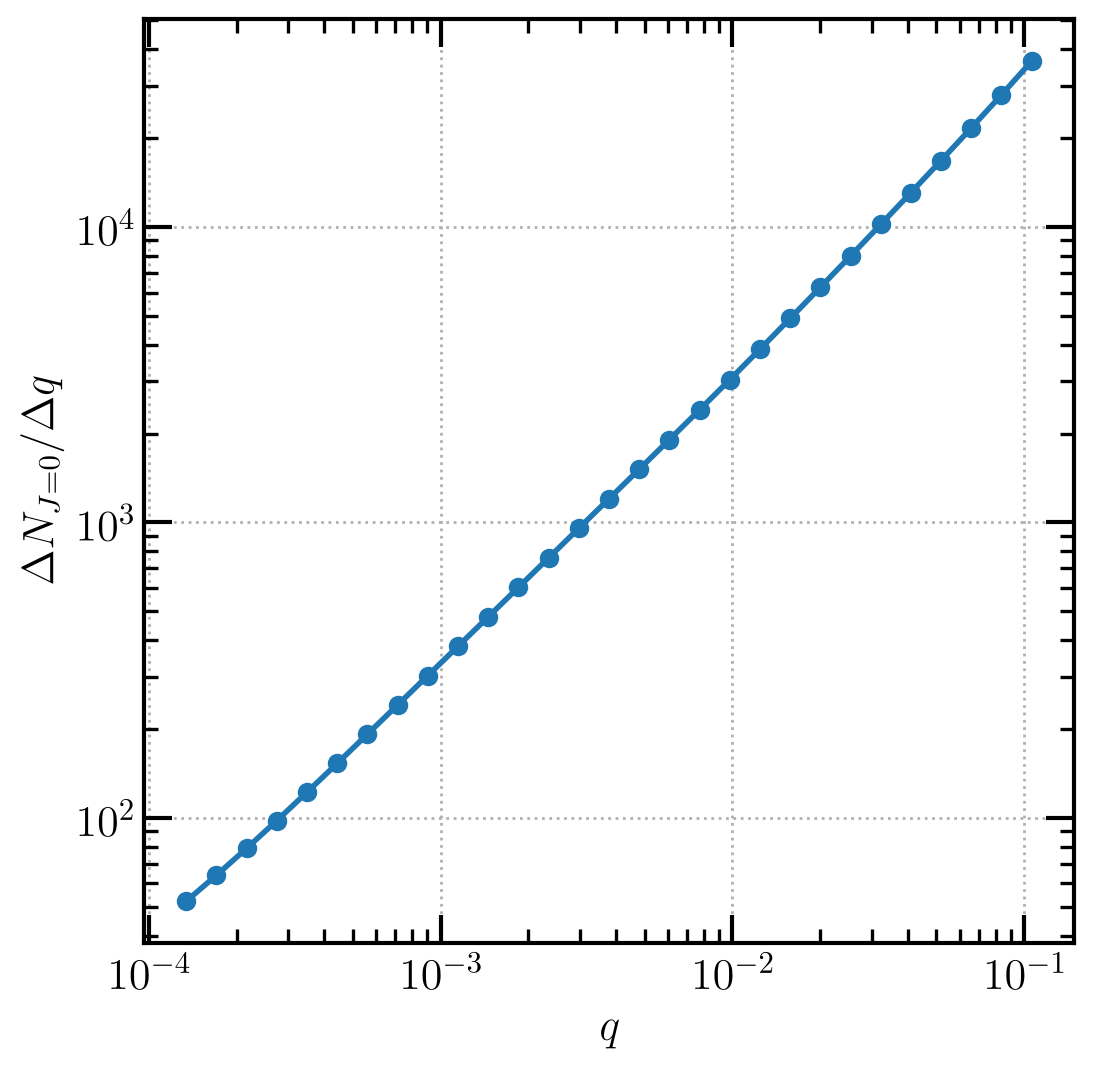

In [6]:
NJ = np.sum(number[:,:,:,0], (0,2))

plt.loglog( (sam.mrat[1:] - sam.mrat[:-1])/2 , NJ, '-o')
plt.xlabel(r"$q$")
plt.ylabel(r"$\Delta N_{J=0}/\Delta q$")

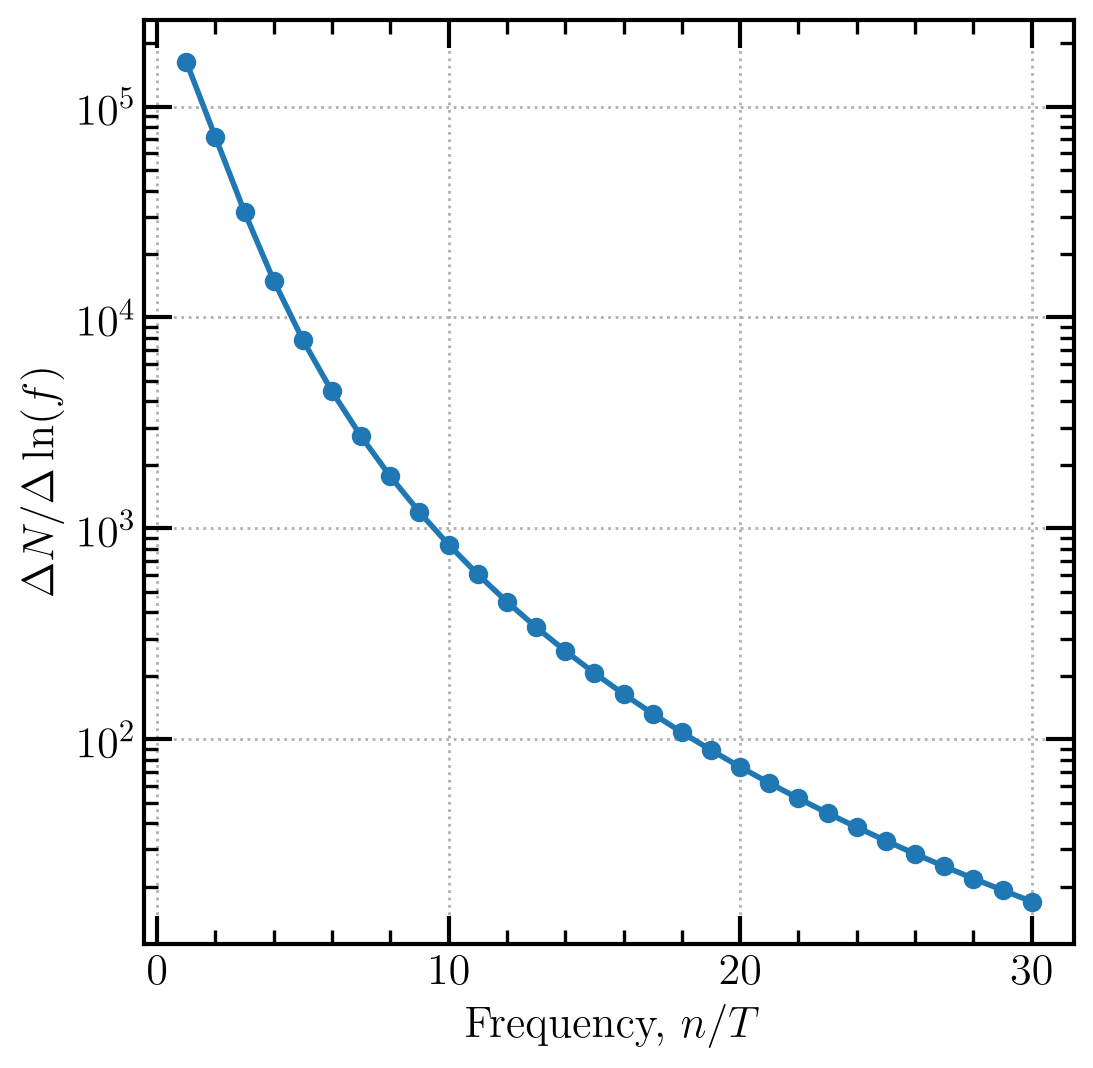

In [7]:
NJ = np.sum(number, (0,1,2))

plt.plot(fobs*OBS_DUR, NJ, '-o')
plt.yscale('log')
plt.xlabel(r"Frequency, $n/T$")
plt.ylabel(r'$\Delta N/ \Delta \ln (f)$');

### Change of sGWB

passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()


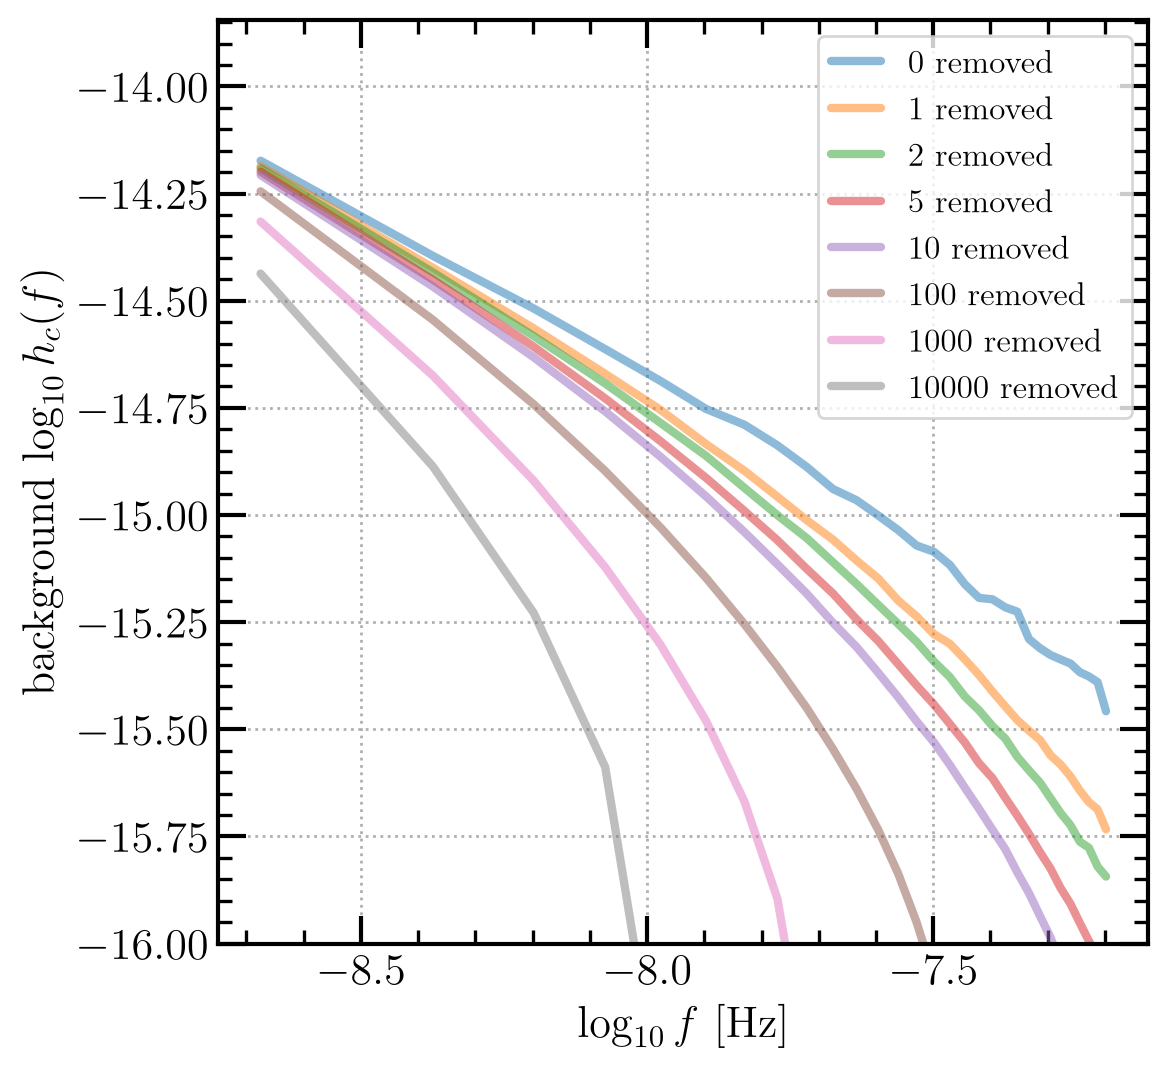

In [8]:
bg = []

src_exc = [0, 1, 2, 5, 10, int(1e2), int(1e3), int(1e4)]

for NUM_LOUDEST in src_exc:
    fobs, fobs_edges = utils.pta_freqs(dur=OBS_DUR, num=NUM_FREQS)
    hard_gw = holo.hardening.Hard_GW()

    lifetime = 1e9 * YR  ## <-- try changing this
    gamma_inner = -1.0 ## <-- try changing this
    hard_ph = holo.hardening.Fixed_Time_2PL_SAM(sam, lifetime, sepa_init=1.0e4*PC, gamma_inner=gamma_inner)
    redz_final, diff_num = holo.sams.sam_cyutils.dynamic_binary_number_at_fobs(
        fobs/2, sam, hard_ph, holo.cosmo
    )

    # ---------------------- #

    hc_ss, hc_bg = sam.gwb(fobs_edges, hard = hard_gw, realize=NUM_REALS, loudest=NUM_LOUDEST)

    bg.append(hc_bg)

    edges = [sam.mtot, sam.mrat, sam.redz, fobs_edges/2]
    number = holo.sams.sam_cyutils.integrate_differential_number_3dx1d(edges, diff_num)

    plt.plot(np.log10(fobs), np.log10(np.average(hc_bg,1)), lw=3, alpha=0.5, label=f'{NUM_LOUDEST} removed');

plt.xlabel(r"$\log_{10} f$ [Hz]")
plt.ylabel(r'background $\log_{10} h_c(f)$')
plt.ylim(-16)
plt.legend(fontsize=12)
plt.legend(fontsize=12)
plt.show()

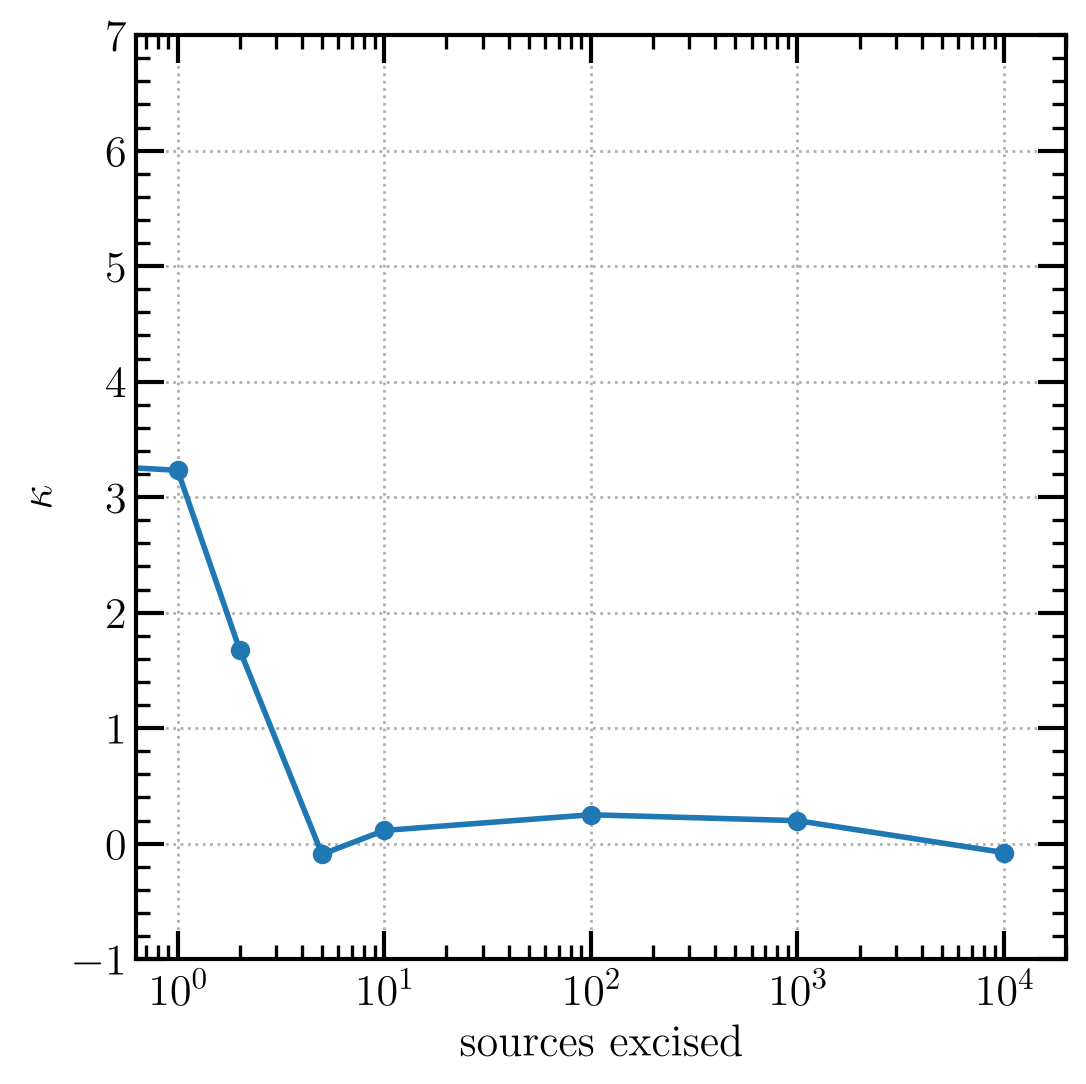

In [9]:
from scipy.stats import kurtosis

bg = np.array(bg)
ref_freq = 2/OBS_DUR # id=1
ref_id = np.argmin(abs(ref_freq-fobs))

k = kurtosis(bg, 2)
m = np.average(bg, 2)
plt.semilogx(src_exc, k[:,ref_id], '-o')
# plt.yscale('log')
plt.xlim(-1,2e4)
plt.ylim(-1,7)
plt.xlabel('sources excised')
plt.ylabel(r'$\kappa$')
plt.show()

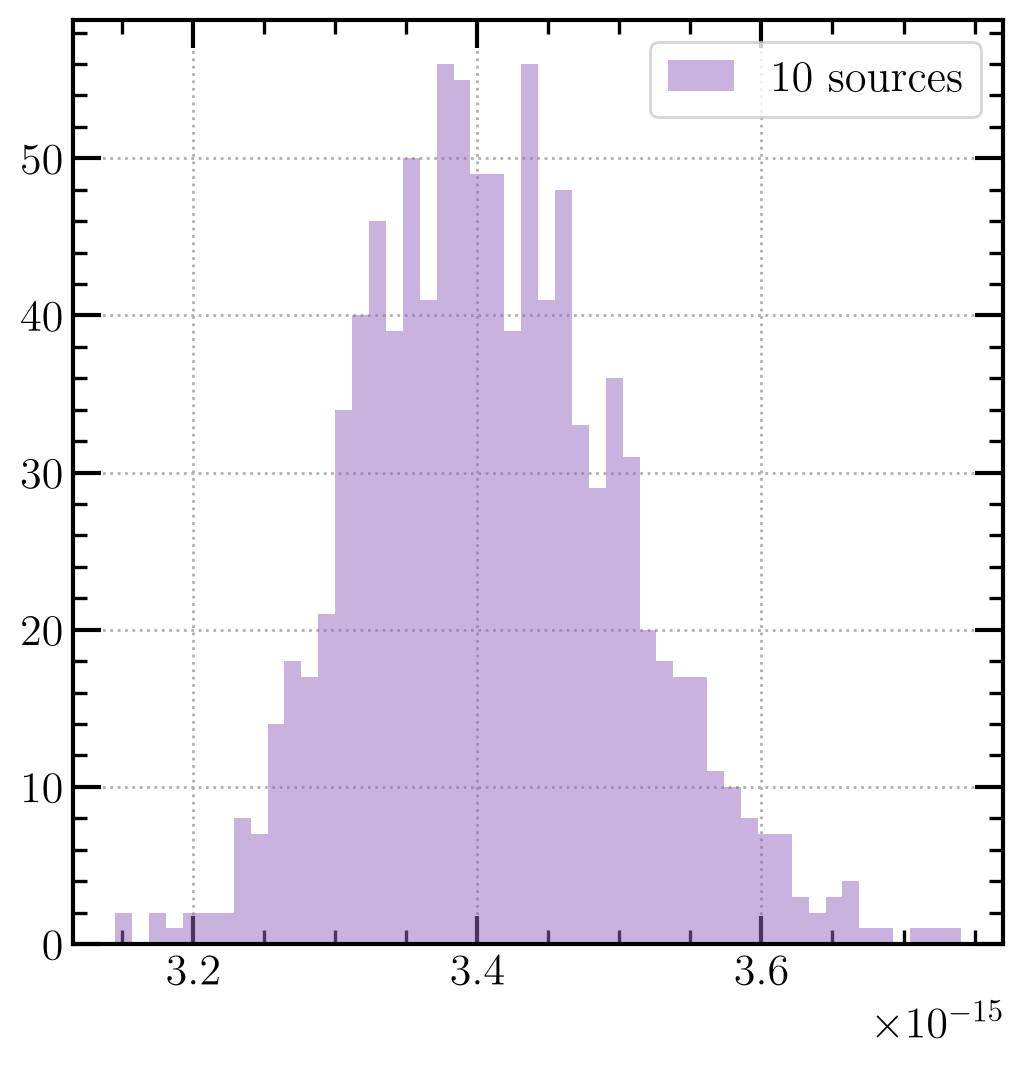

In [10]:
i = 4
plt.hist(bg[i, ref_id, :], bins=50, color=f'C{i}',alpha=0.5, label=f'{src_exc[i]} sources')
plt.legend()
plt.show()

### Calc AJ

In [11]:
fobs, fobs_edges = utils.pta_freqs(dur=OBS_DUR, num=NUM_FREQS)
hard_gw = holo.hardening.Hard_GW()

lifetime = 1e9 * YR  ## <-- try changing this
gamma_inner = -1.0 ## <-- try changing this
hard_ph = holo.hardening.Fixed_Time_2PL_SAM(sam, lifetime, sepa_init=1.0e4*PC, gamma_inner=gamma_inner)
redz_final, diff_num = holo.sams.sam_cyutils.dynamic_binary_number_at_fobs(
    fobs, sam, hard_ph, holo.cosmo
)

# ---------------------- #

hc_ss_gw, hc_gw = sam.gwb(fobs_edges, hard = hard_gw, realize=NUM_REALS, loudest=NUM_LOUDEST)

hc_ss, hc_true = sam.gwb(fobs_edges, hard = hard_ph, realize=NUM_REALS, loudest=NUM_LOUDEST)

edges = [sam.mtot, sam.mrat, sam.redz, fobs_edges]
number = holo.sams.sam_cyutils.integrate_differential_number_3dx1d(edges, diff_num)

passed redz check at the beginning of ss_gws_redz()
passed redz check at the beginning of ss_gws_redz()


In [12]:
from astropy import constants

mtot = (sam.mtot[1:] + sam.mtot[:-1])/2
mrat = (sam.mrat[1:] + sam.mrat[:-1])/2
redz = (sam.redz[1:] + sam.redz[:-1])/2
mc = utils.chirp_mass_mtmr(mtot[:,None,None,None], mrat[None, :, None, None])
dc = holo.cosmo.z_to_dcom(redz[None, None, :, None])          # distanza comovente
frst = fobs[None,None,None,:] * (1.0 + redz[None, None, :, None])         # frequenza GW nel rest-frame
A_j = utils.gw_strain_source(mc, dc, fobs)

print(A_j[np.argmin(abs(mtot - 1e9*constants.M_sun.cgs.value)), np.argmin(abs(mrat - 1)), np.argmin(abs(redz - .01)), np.argmin(abs(fobs - 3e-9))])

# print(np.sum(A_j, (0,1,2)))
# print(A_j[np.argmin(abs(mtot - 1e9*constants.M_sun.cgs.value)), np.argmin(abs(mrat - 1)), np.argmin(abs(redz - .01)), np.argmin(abs(fobs - 3e-9))])
# np.log10(sam.mtot/constants.M_sun.cgs.value)[-5]


1.1103071038268447e-15


[9.73141351e-02 9.53857532e-01 4.07188030e+00 1.16048622e+01
 2.62470899e+01 5.11843671e+01 9.00495526e+01 1.46835034e+02
 2.25841927e+02 3.31537824e+02 4.67352759e+02 6.37781598e+02
 8.48733552e+02 1.10548568e+03 1.41010793e+03 1.76704050e+03
 2.18961869e+03 2.66700185e+03 3.22250130e+03 3.82767735e+03
 4.47635061e+03 5.24223088e+03 6.13086382e+03 7.06137175e+03
 8.00069685e+03 9.10344916e+03 1.02530720e+04 1.15001541e+04
 1.29707944e+04 1.43696792e+04]


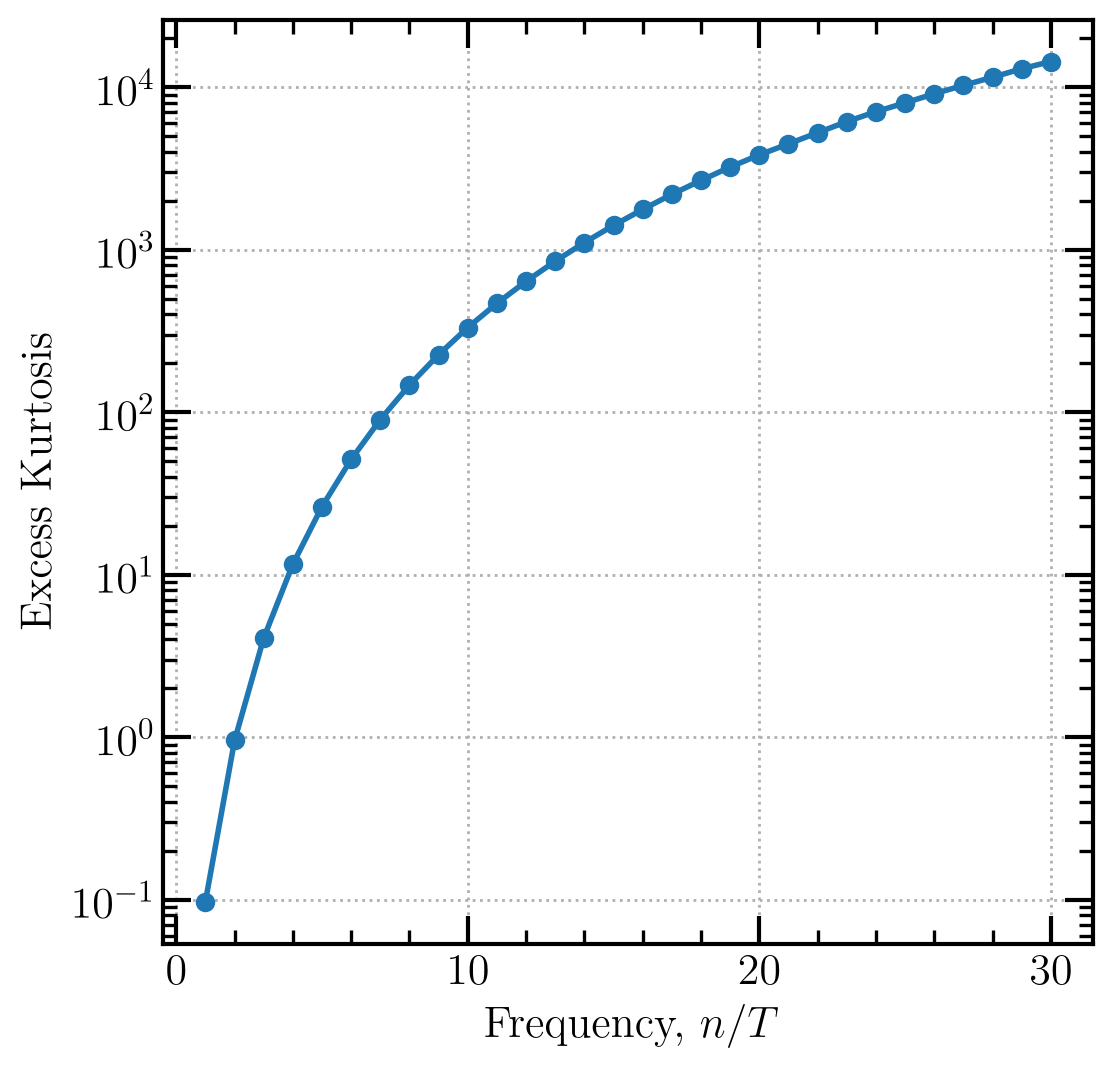

In [13]:
N_j = number

num = np.sum(N_j * A_j**4 / fobs**4, axis=(0,1,2))
den = np.sum(N_j * A_j**2 / fobs**2, axis=(0,1,2))
k_i = num / den**2

print(k_i)
plt.semilogy(fobs*OBS_DUR, k_i, '-o')
plt.xlabel(r"Frequency, $n/T$")
plt.ylabel(r"Excess Kurtosis")
plt.show()

#### Montecarlo

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import holodeck as holo
from holodeck import utils
from holodeck.constants import YR, PC, MSOL, MPC

# ---------------------------------------------------------
# 1. PTA Parameters
# ---------------------------------------------------------
OBS_DUR   = 15 * YR
NUM_FREQS = 30
NUM_REALS = 1000

fobs, fobs_edges = utils.pta_freqs(dur=OBS_DUR, num=NUM_FREQS)   # Observed GW frequencies

# ---------------------------------------------------------
# 2. SAM Population
# ---------------------------------------------------------
gsmf = holo.sams.GSMF_Schechter()                    # Galaxy Stellar-Mass Function (GSMF)
gpf = holo.sams.GPF_Power_Law()                      # Galaxy Pair Fraction         (GPF)
gmt = holo.sams.GMT_Power_Law()                      # Galaxy Merger Time           (GMT)
mmbulge = holo.host_relations.MMBulge_MM2013()       # M-MBulge Relation            (MMB)
sam = holo.sams.Semi_Analytic_Model(
    mtot=(1.0e8*MSOL, 1.0e11*MSOL, 51),
    mrat=(0.001, 1, 51),
    redz=(0.001, 1, 51),
    gsmf=gsmf, gpf=gpf, gmt=gmt, mmbulge=mmbulge, shape=shape)
hard = holo.hardening.Fixed_Time_2PL_SAM(sam, 1e9*YR, sepa_init=1.0e4*PC, gamma_inner=-1.0)

redz_final, diff_num = holo.sams.sam_cyutils.dynamic_binary_number_at_fobs(
    fobs/2, sam, hard, holo.cosmo
)
edges = [sam.mtot, sam.mrat, sam.redz, fobs_edges/2]
number = holo.sams.sam_cyutils.integrate_differential_number_3dx1d(edges, diff_num)  # (M-1,Q-1,Z-1,F)
N_mean_per_bin = number.sum(axis=(0, 1, 2))   # (F,) Expected mean number of sources per bin

# Bin centers for mtot, mrat, redz to assign parameters to sampled binaries
mtot_c = 0.5*(sam.mtot[:-1] + sam.mtot[1:])
mrat_c = 0.5*(sam.mrat[:-1] + sam.mrat[1:])
redz_c = 0.5*(sam.redz[:-1] + sam.redz[1:])
MM, QQ, ZZ = np.meshgrid(mtot_c, mrat_c, redz_c, indexing='ij')
MM, QQ, ZZ = MM.ravel(), QQ.ravel(), ZZ.ravel()

# ---------------------------------------------------------
# 3. Monte Carlo Simulation of Fourier Coefficients (scalar toy model)
# ---------------------------------------------------------
A_k = np.zeros((NUM_FREQS, NUM_REALS))
B_k = np.zeros((NUM_FREQS, NUM_REALS))

for k in range(NUM_FREQS):
    weights = number[:, :, :, k].ravel()
    wsum = weights.sum()
    if wsum <= 0:
        continue
    probs = weights / wsum

    for r in range(NUM_REALS):
        n_sources = np.random.poisson(N_mean_per_bin[k])
        if n_sources == 0:
            continue

        # Sample n_sources binaries from the distribution (mtot, mrat, redz) weighted by expected count
        idx = np.random.choice(MM.size, size=n_sources, p=probs)
        mt, q, z = MM[idx], QQ[idx], ZZ[idx]

        m1, m2 = utils.m1m2_from_mtmr(mt, q)
        mc = utils.chirp_mass_mtmr(mt, q)
        dc = holo.cosmo.z_to_dcom(z)          # Comoving distance
        frst = fobs[k] * (1.0 + z)         # Rest-frame GW frequency

        h0 = utils.gw_strain_source(mc, dc, frst)    # Characteristic strain per source
        phi = np.random.uniform(0, 2*np.pi, size=n_sources)

        A_k[k, r] = np.sum(h0 * np.cos(phi))
        B_k[k, r] = np.sum(h0 * np.sin(phi))

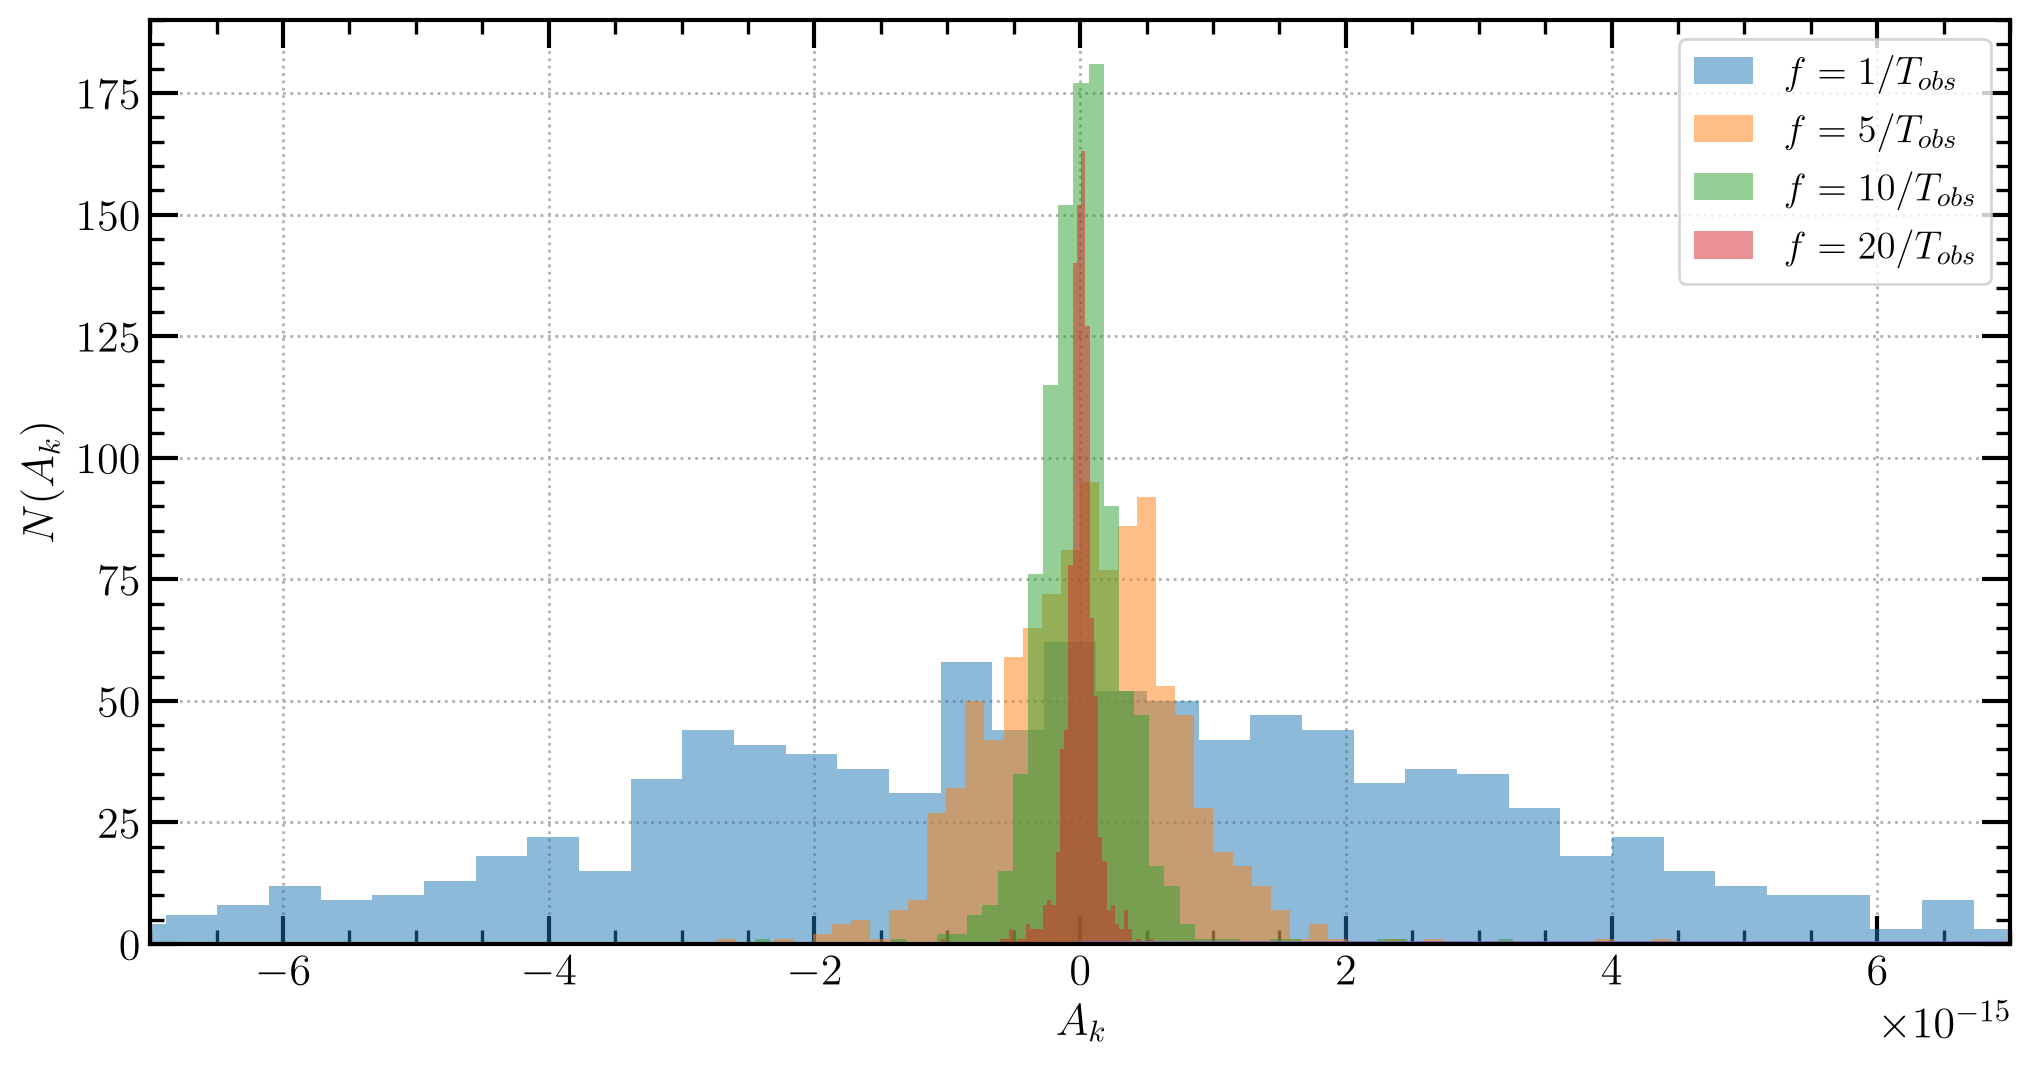

In [22]:
from scipy.stats import norm

plt.subplots(figsize=(12,6))

for i in [0,4,9,19]:
    plt.hist(A_k[i, :], bins=50,alpha=0.5, label=fr'$f = {fobs[i]*OBS_DUR:.0f}/T_{{{{obs}}}}$')

plt.plot(np.linspace(-7*1e-15, 7*1e-15, int(1e3)),)
plt.xlim(-7*1e-15,7*1e-15)
# plt.ylim(0,.2)
plt.xlabel(r'$A_k$')
plt.ylabel(r'$N(A_k)$')
plt.legend(fontsize=14)
plt.show()

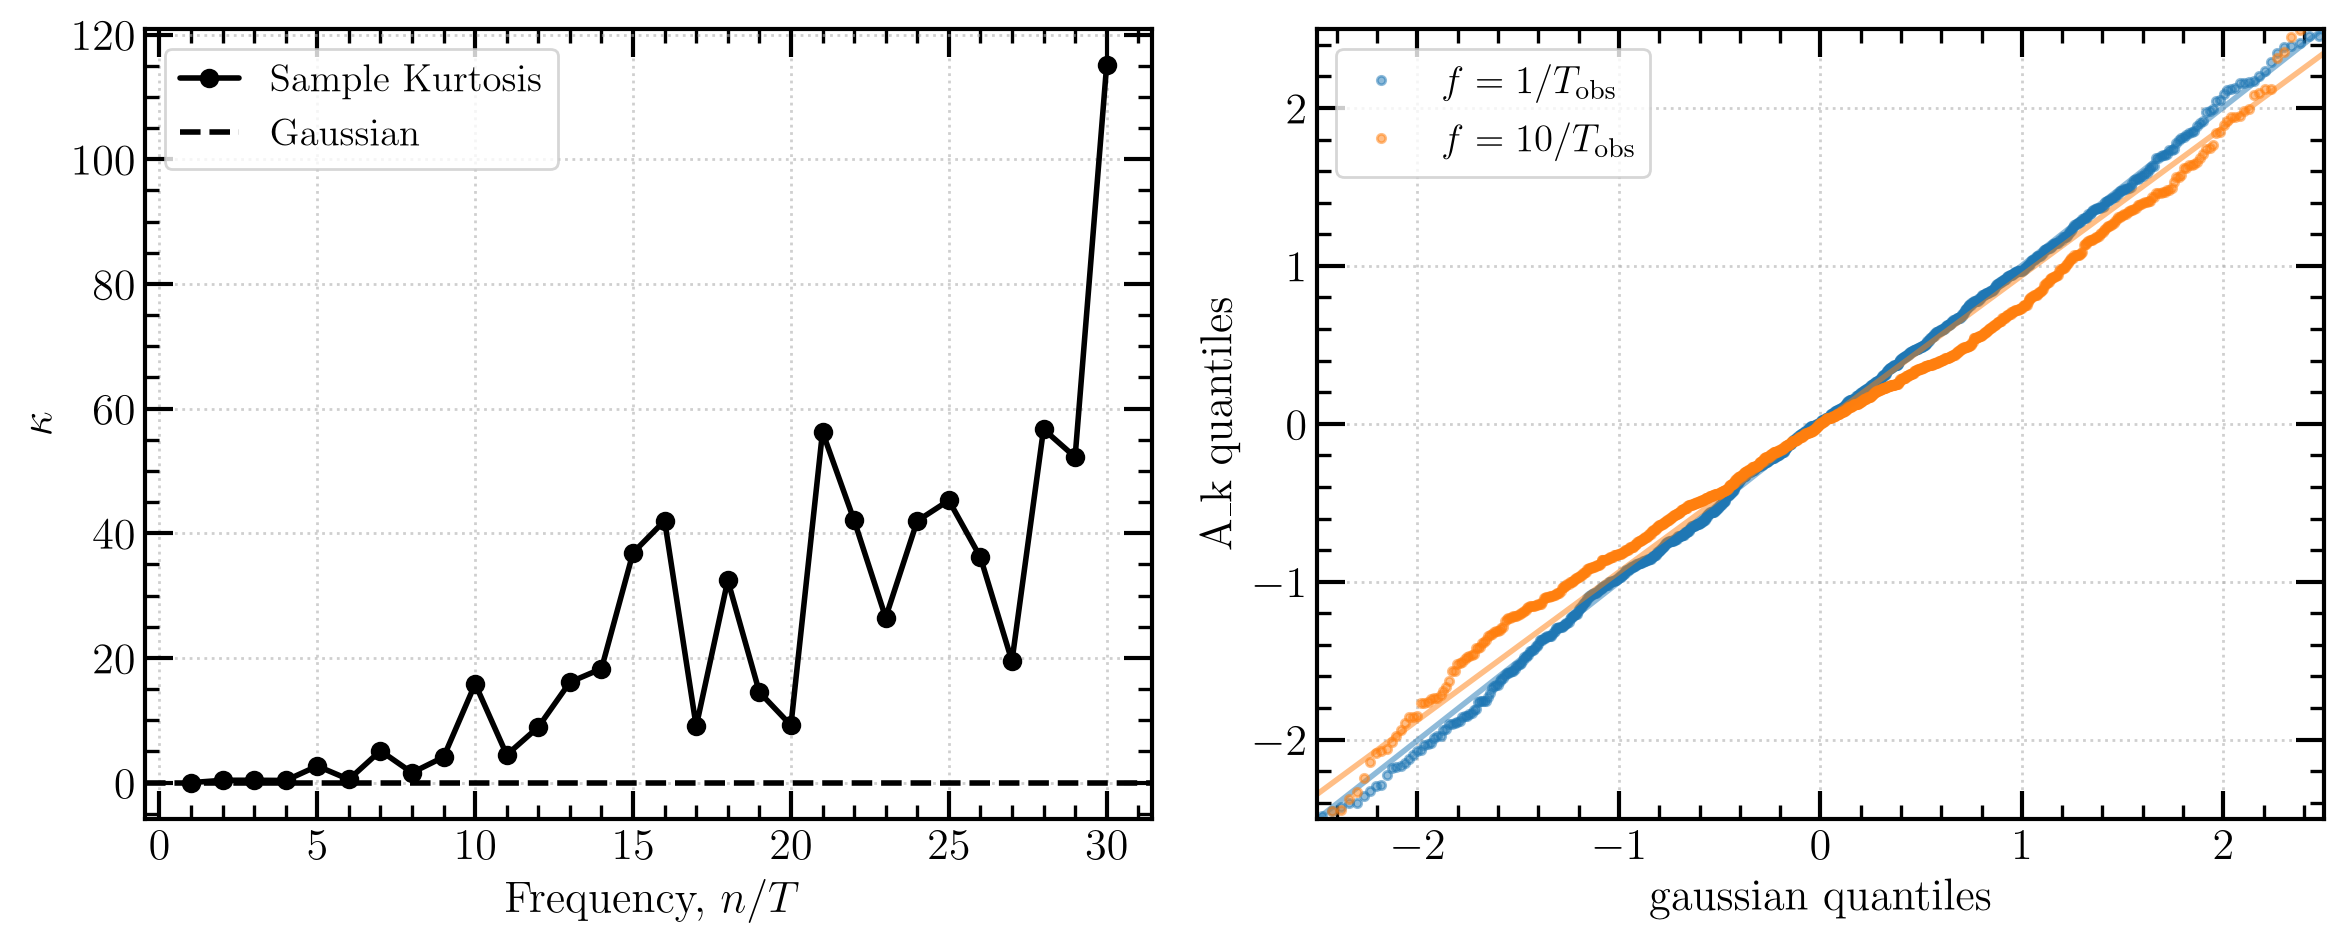

In [16]:
# ---------------------------------------------------------
# 4. Normalization and Kurtosis per Frequency Bin
# ---------------------------------------------------------
A_k_norm = np.zeros_like(A_k)
kurtosis_per_bin = np.zeros(NUM_FREQS)

for k in range(NUM_FREQS):
    std_A, mean_A = np.std(A_k[k, :]), np.mean(A_k[k, :])
    if std_A > 0:
        A_k_norm[k,:] = A_k[k,:]
        A_k_norm[k, :] = (A_k[k, :] - mean_A) / std_A
    kurtosis_per_bin[k] = stats.kurtosis(A_k_norm[k, :], fisher=True)

# ---------------------------------------------------------
# 5. Plotting
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: Excess Kurtosis vs GW Frequency
axes[0].plot(fobs * OBS_DUR, kurtosis_per_bin, 'o-', color='black', label='Sample Kurtosis')
axes[0].axhline(0, color='black', linestyle='--', label='Gaussian')
axes[0].set_xlabel(r"Frequency, $n/T$")

axes[0].set_ylabel(r'$\kappa$')
axes[0].legend(fontsize=14)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Subplot 2: QQ-plot comparison
res_low = stats.probplot(A_k_norm[0, :], dist="norm", plot=axes[1])
res_high = stats.probplot(A_k_norm[9, :], dist="norm", plot=axes[1])

# Apply consistent standard colors and add explicit legend entries
lines = axes[1].get_lines()
lines[0].set(markersize=3, color='C0', alpha=0.5, label=rf'$f = {fobs[0]*OBS_DUR:.0f}/T_{{ \mathrm {{obs}} }}$')
lines[1].set(color='C0', alpha=0.5)
lines[2].set(markersize=3, color='C1', alpha=0.5, label=rf'$$f = {fobs[9]*OBS_DUR:.0f}/T_{{ \mathrm {{obs}} }}$$')
lines[3].set(color='C1', alpha=0.5)

axes[1].set_title("")
axes[1].set_xlabel('gaussian quantiles')
axes[1].set_ylabel('A_k quantiles')
axes[1].set_xlim(-2.5, 2.5)
axes[1].set_ylim(-2.5, 2.5)
axes[1].legend(fontsize=14)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

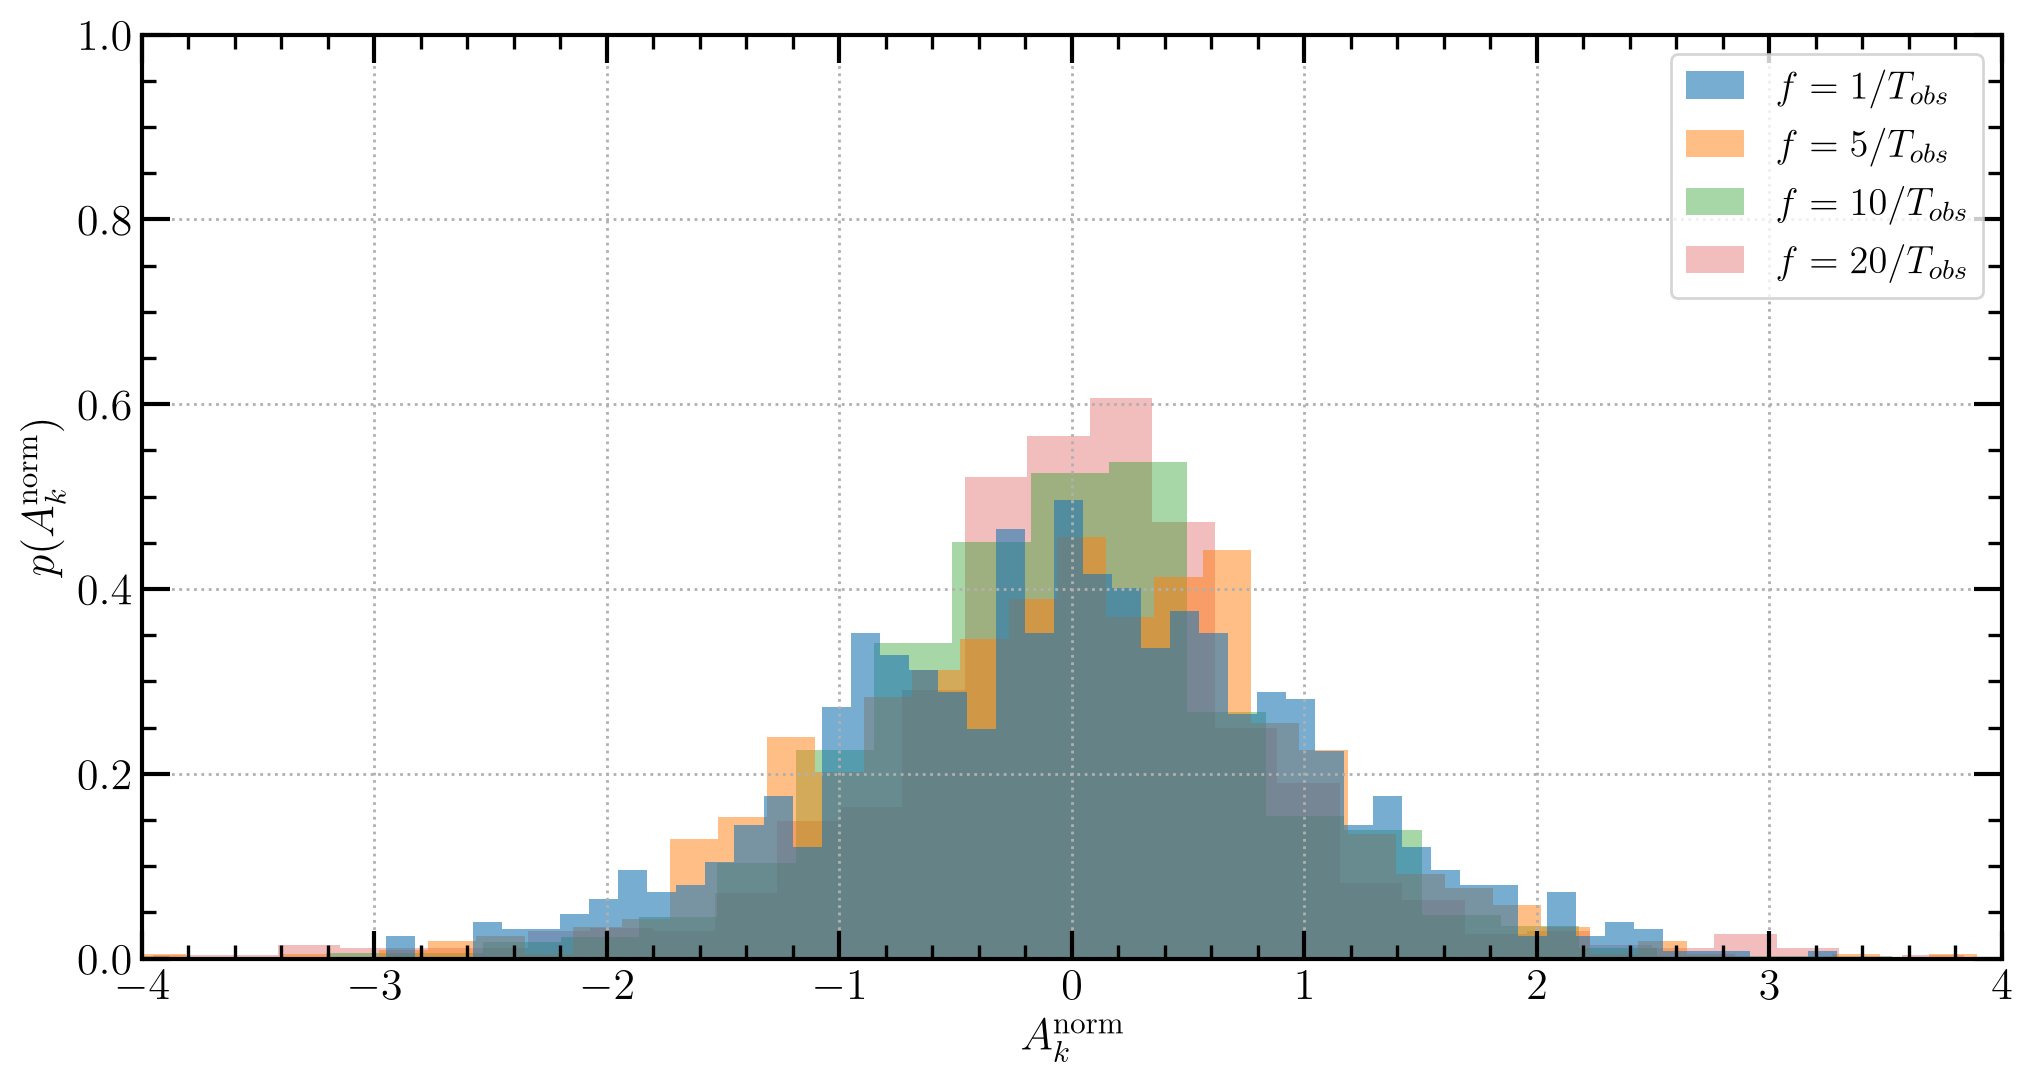

In [17]:
plt.subplots(figsize=(12,6))

for i in [0,4,9,19]:
    plt.hist(A_k_norm[i, :], density=True, bins=50, alpha=0.6/(i/20+1), zorder=-i, label=fr'$f = {fobs[i]*OBS_DUR:.0f}/T_{{{{obs}}}}$')

plt.xlim(-4,4)
plt.ylim(0,1)
plt.xlabel(r'$A_k^\mathrm{norm}$')
plt.ylabel(r'$p(A_k^\mathrm{norm})$')
plt.legend(fontsize=14)
plt.show()

### Old code

In [18]:
# from astropy.cosmology import Planck15
# from astropy import constants

# cosmo = Planck15

# def get_ampli_vec(M, mrat, z, f):
#     c = constants.c.cgs.value
#     g = constants.G.cgs.value
#     d_l = cosmo.luminosity_distance(z).cgs.value  # shape (len(z),)

#     # chirp mass, shape (M, mrat, 1, 1) so it broadcasts against z and f
#     Mc = M[:,None,None,None] * (mrat[None,:,None,None] / (1+mrat[None,:,None,None])**2)**(3/5)

#     d_l = d_l[None,None,:,None]        # (1,1,z,1)
#     f   = np.asarray(f)[None,None,None,:]  # (1,1,1,freq)

#     A = 2 * (g*Mc)**(5/3) / (d_l*c**4) * (np.pi*f*(1+z))**(2/3)
#     return A  # shape (M, mrat, z, freq)


# mtot = (sam.mtot[1:] + sam.mtot[:-1])/2
# mrat = (sam.mrat[1:] + sam.mrat[:-1])/2
# redz = (sam.redz[1:] + sam.redz[:-1])/2
# A_j = get_ampli_vec(sam.mtot, sam.mrat, sam.redz, fobs)

# # print(np.sum(A_j, (0,1,2)))
# print(A_j[np.argmin(abs(mtot - 1e9*constants.M_sun.cgs.value)), np.argmin(abs(mrat - 1)), np.argmin(abs(redz - .01)), np.argmin(abs(fobs - 3e-9))])
# # np.log10(sam.mtot/constants.M_sun.cgs.value)[-5]
